# Направление C — микроструктура/поток + тройной барьер + мета-лейблинг

**Единый драйвер `run_direction_c.ipynb`.** Ноутбук сначала **верифицирует код и проверяет
отсутствие утечек** (раздел §3 — это ГЕЙТ), и только затем обучает и оценивает модели. Логика
не дублируется — вызываются функции из `v2_microstructure/src/`; результаты показываются и
сохраняются в `figures/` и `reports/<run_id>/`.

**Постановка.** Цель — вол-масштабированный **тройной барьер** `{+1, 0, −1}` (зависит от пути,
нормирован на волатильность) вместо одношагового `r_t`/directional accuracy. Признаки — поток и
деривативы (funding/basis) плюс **прокси микроструктуры из klines** (taker-buy imbalance, CVD,
bar-VPIN; это НЕ тиковая микроструктура). Судья — экономика после издержек на **де-перекрытых
сделках**, а не accuracy. Инструмент торговли/PnL — перп `BTCUSDT`.

> **Жёсткая планка (hard-bar).** Финальный критерий DSR ≥ 0.95 считается на **де-перекрытых
> trade-ретёрнах** (их сотни, не 21k баров) — это намеренно строгая планка с широким
> доверительным интервалом. **Большинство конфигураций её не пройдут — это так и задумано,
> а не баг.** Развёртывание: `DSR ≥ 0.95 И PBO ≤ 0.5`.

**Объём этого ноутбука — §0–§7 (вехи M0–M3).** Разделы §8–§12 (Stage-2 мета, стратегия,
DSR/PBO/breakeven, отчёт, вскрытие holdout) добавятся после реализации M4–M5 — внизу есть
помеченная отключённая ячейка-заглушка.


## Схема конвейера

Если Mermaid не отрендерился в вашем окружении — ниже приведена ASCII-схема (она эквивалентна).

```mermaid
flowchart LR
  A[snapshot<br/>perp+spot+funding+CoinMetrics] --> B[labeling<br/>triple-barrier {+1,0,-1}]
  B --> C[features<br/>flow / micro / control]
  C --> D[Stage-1 ladder<br/>baseline→logit→LightGBM]
  D --> E[M3 ablation gate<br/>flow vs control, de-overlapped]
  E -->|continue| F[(Stage-2 meta · strategy · evaluate · reports)]
  E -->|kill-switch| G[(backlog B: StatArb)]
```

```text
ASCII fallback:
  snapshot ──▶ labeling(triple-barrier) ──▶ features(flow|micro|control) ──▶ Stage-1 ladder
       ──▶ M3 ablation gate (flow vs control, de-overlapped trade returns)
              │ continue ─▶ [Stage-2 meta → strategy(net pos, funding, PnL split) → evaluate → reports]   (M4–M5)
              │ kill     ─▶ [backlog B: market-neutral StatArb]

  Внутри сделки:  primary(side ±1) ─▶ meta(p_ok → size) ─▶ strategy(net position, funding carry, price/funding PnL split)
```


## §1. Окружение и конфигурация

**Что делаем:** подключаем пакет, фиксируем seed, печатаем конфиг и режим `QUICK_MODE`,
считаем хэш лок-файла окружения.
**Зачем:** детерминизм и воспроизводимость — «результат изменился» нельзя спутать с шумом seed.
**На что смотреть:** `QUICK_MODE`, сетки барьеров/издержек, `LEGACY_LIB` найдена, hash окружения.


In [1]:
import sys, pathlib, json, subprocess
# найти корень репозитория (где лежит пакет v2_microstructure) и сделать его импортируемым
_p = pathlib.Path.cwd().resolve()
REPO_ROOT = next((q for q in [_p, *_p.parents] if (q / "v2_microstructure").is_dir()), _p)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np, pandas as pd
from IPython.display import Image, display
from v2_microstructure.src import (config, data_snapshot as ds, labeling as lb,
                                    features as ft, primary_model as pm, evaluate as ev,
                                    tripwires as tw, run_manifest as rm, plots, experiment as ex)
from ml_models import set_global_seed
set_global_seed(config.SEED)

print("QUICK_MODE      :", config.QUICK_MODE, "  (False = полный прогон)")
print("seed            :", config.SEED)
print("LEGACY_LIB      :", config.LEGACY_LIB, "| free_features:", (config.LEGACY_LIB/'free_features.py').exists())
print("barrier grid    : k=", config.k_grid(), " H=", config.h_grid(), " sigma_span=", config.SIGMA_SPAN_DEFAULT)
print("cost (round-trip):", ev.default_cost(), " | sweep bp:", config.COST_SWEEP_RT_BPS[:5], "...")
print("CPCV            : N=", config.CPCV_N, " k=", config.CPCV_K, " | holdout cut:", config.HOLDOUT_CUT)
print("deploy rule     : DSR >=", config.DSR_MIN, " AND PBO <=", config.PBO_MAX)
env = rm.env_lockfile()
print("env lockfile    : python", env["python"], "| sha", env["sha256"][:12])

/Users/tigran/python_projects_epta/personal_projects/diploma/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


QUICK_MODE      : True   (False = полный прогон)
seed            : 42
LEGACY_LIB      : /Users/tigran/python_projects_epta/personal_projects/diploma/ACTUAL_VERSION | free_features: True
barrier grid    : k= (1.5,)  H= (24,)  sigma_span= 48
cost (round-trip): 0.0014  | sweep bp: (0, 2, 4, 6, 8) ...
CPCV            : N= 6  k= 2  | holdout cut: 2025-06-01
deploy rule     : DSR >= 0.95  AND PBO <= 0.5
env lockfile    : python 3.11.15 | sha 5acda9d3baa5


## §2. Данные: аудит источников и замороженный снапшот

**Что делаем:** печатаем аудит источников (earliest ts + гранулярность, эффективный диапазон),
затем читаем **замороженный** parquet (`load_snapshot`; при отсутствии — `build_snapshot`).
**Зачем:** сеть трогаем только здесь; всё остальное — из замороженного снапшота с проверкой хэша.
**На что смотреть:** эффективный диапазон, content hash, формы/пропуски.


In [2]:
audit = ds.audit_sources()
print("эффективный диапазон:", audit["effective_start"], "→", audit["effective_end"])
for k, v in audit["sources"].items():
    print(f"  {k:12s} earliest={v['earliest']}  gran={v.get('granularity')}")

try:
    snap = ds.load_snapshot()           # читает только замороженный файл + сверяет хэш
    print("\nload_snapshot: OK (hash verified)")
except FileNotFoundError:
    print("\nснапшот не найден — строю заново (единственная сетевая операция)")
    snap = ds.build_snapshot()

man = json.loads(config.SNAPSHOT_MANIFEST.read_text())
print("range:", man["effective_range"], "| sha:", man["content_sha256"][:12])
print("columns:", list(snap.columns))
display(snap[["perp_close","funding","basis","tfi","cvd","vpin"]].describe().round(5))
print("NaN на колонку:\n", snap.isna().sum().to_string())

эффективный диапазон: 2019-09-10 08:00:00 → 2026-06-18 22:00:00
  perp_klines  earliest=2019-09-08 17:00:00  gran=1h
  spot_klines  earliest=2017-08-17 04:00:00  gran=1h
  funding      earliest=2019-09-10 08:00:00  gran=8h
  coinmetrics  earliest=2009-01-03 00:00:00  gran=1d

load_snapshot: OK (hash verified)
range: {'start': '2019-09-10 08:00:00', 'end': '2026-06-18 19:00:00', 'n_rows': 59364} | sha: 3e3b816e5c0a
columns: ['perp_close', 'spot_close', 'perp_volume', 'tfi', 'cvd', 'vpin', 'basis', 'basis_chg', 'funding', 'funding_chg', 'active_addr_chg', 'tx_cnt_chg', 'addr_bal_chg', 'hashrate_chg', 'supply_chg']


,perp_close,funding,basis,tfi,cvd,vpin
count,59364.00000,59364.00000,59328.00000,59364.00000,59364.00000,59355.00000
mean,47284.29503,0.00011,-0.00012,-0.00513,-0.00355,0.07208
std,31646.69102,0.00021,0.00064,0.09582,0.01521,0.03087
min,4062.89000,-0.00300,-0.02573,-0.81270,-0.05950,0.02588
25%,20740.65000,0.00003,-0.00049,-0.06250,-0.00468,0.05593
50%,41015.45000,0.00010,-0.00036,-0.00548,-0.00324,0.06847
75%,67556.35000,0.00010,0.00011,0.05230,-0.00256,0.08194
max,125986.00000,0.00300,0.03320,0.89109,0.79212,0.48690


NaN на колонку:
 perp_close          0
spot_close         36
perp_volume         0
tfi                 0
cvd                 0
vpin                9
basis              36
basis_chg          37
funding             0
funding_chg         8
active_addr_chg    16
tx_cnt_chg         16
addr_bal_chg       16
hashrate_chg       16
supply_chg         16


## §3. Верификация и анти-утечка — ГЕЙТ до обучения

**Что делаем:** (а) юнит-тесты `tests/test_v2_*.py`; (б) tripwires утечки на реальных признаках
(label-shuffle → метрики ~0; аудит доступности в t−1; доминирование фичи; одноклассовость);
(в) проверка воспроизводимости (один seed+hash → идентичные разметка/признаки).
**Зачем:** «слишком хороший» результат — это баг утечки, пока не доказано обратное. Если что-то
красное — `assert` останавливает ноутбук ДО обучения.
**На что смотреть:** `ALL GREEN`. Иначе — стоп.


In [4]:
# (а) юнит-тесты как подпроверка
tests = [str(config.LEGACY_LIB/"tests"/f) for f in
         ("test_v2_labeling.py","test_v2_features.py","test_v2_gate.py")]
rc = subprocess.run([sys.executable,"-m","pytest",*tests,"-q","-p","no:cacheprovider"],
                    cwd=str(REPO_ROOT)).returncode
print("pytest returncode:", rc)

# подготовка для tripwires: dev-срез, разметка по умолчанию, признаки flow-плеча
dev, hold = lb.seal_holdout(snap.index)
close_dev = snap.loc[dev.to_numpy(), "perp_close"]
X, meta = ft.build_features(snap, dev_mask=dev)
L = lb.triple_barrier_labels(close_dev, k=config.K_DEFAULT, H=config.H_DEFAULT)
Xa, y, w = ft.align_xy(X, L, cols=meta["arm_flow"])

# (б) tripwires
import lightgbm as lgb
from sklearn.metrics import matthews_corrcoef
res = []
res.append(tw.single_class_guard(y))
r_t = np.log(close_dev).diff().reindex(Xa.index)
res.append(tw.t_minus_1_availability_audit(Xa, r_t))
cut = int(0.7*len(Xa))
def _fit(Xt, yt, wt):
    m = lgb.LGBMClassifier(n_estimators=config.lgbm_n_estimators(), num_leaves=31,
                           learning_rate=0.05, min_child_samples=100, random_state=config.SEED,
                           n_jobs=-1, verbose=-1)
    m.fit(Xt, yt, sample_weight=wt); return m
m_real = _fit(Xa.iloc[:cut], y.iloc[:cut], w.iloc[:cut])
imp = dict(zip(Xa.columns, m_real.feature_importances_.astype(float)))
res.append(tw.feature_dominance_flag(imp))
rng = np.random.default_rng(0); ysh = y.iloc[:cut].to_numpy().copy(); rng.shuffle(ysh)
m_sh = _fit(Xa.iloc[:cut], pd.Series(ysh, index=y.index[:cut]), w.iloc[:cut])
mcc_sh = matthews_corrcoef(y.iloc[cut:], m_sh.predict(Xa.iloc[cut:]))
res.append({"check":"label_shuffle","passed":abs(mcc_sh)<0.05,"shuffled_mcc":float(mcc_sh)})
for rr in res: print(rr)
summary = tw.summarize(res)

# (в) воспроизводимость: разметка и признаки байт-идентичны при повторном построении
L2 = lb.triple_barrier_labels(close_dev, k=config.K_DEFAULT, H=config.H_DEFAULT)
X2, _ = ft.build_features(snap, dev_mask=dev)
repro = bool((L.frame["sample_weight"].to_numpy() == L2.frame["sample_weight"].to_numpy()).all()
             and X[meta["arm_flow"]].equals(X2[meta["arm_flow"]]))
print("\nреспроизводимость (labels+features идентичны):", repro)
print("tripwire summary:", summary)

assert rc == 0, "юнит-тесты упали — стоп до обучения"
assert summary["all_passed"], f"красные tripwires: {summary['red']} — стоп до обучения"
assert repro, "разметка/признаки не воспроизвелись — стоп"
print("\n=== §3 GATE: ALL GREEN — можно обучать ===")

........................                                                 [100%]
=============================== warnings summary ===============================
.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:64
  /Users/tigran/python_projects_epta/personal_projects/diploma/.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
    prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85
.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85
.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85
.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85
.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85
.venv/lib/python3.11/site-packages/matplotlib/_fontconfig_pattern.py:85
  /Users/tigran/python_projects_epta/personal_pro

## §4. Разметка: тройной барьер

**Что делаем:** строим метки по сетке `k/H` на dev; печатаем баланс (+1/0/−1), частоту сделок,
эффективную выборку Σ-uniqueness; рисуем барьеры на куске цены.
**Зачем:** если вертикали (0) доминируют → мало сделок; это ловится здесь, до моделей.
**На что смотреть:** симметрия ±1, доля 0, `barrier/cost ≫ 1`, эффективная выборка.


,k,H,+1,0,-1,trade_freq,eff_N,bar/cost,hold
0,1.5,24,0.481,0.056,0.463,0.944,7171.847,5.6,7.521


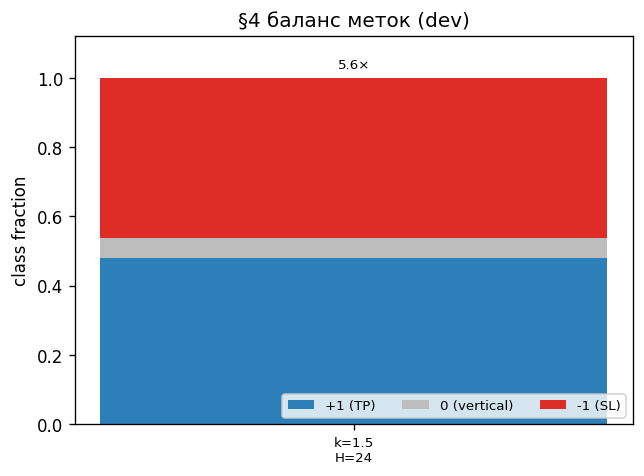

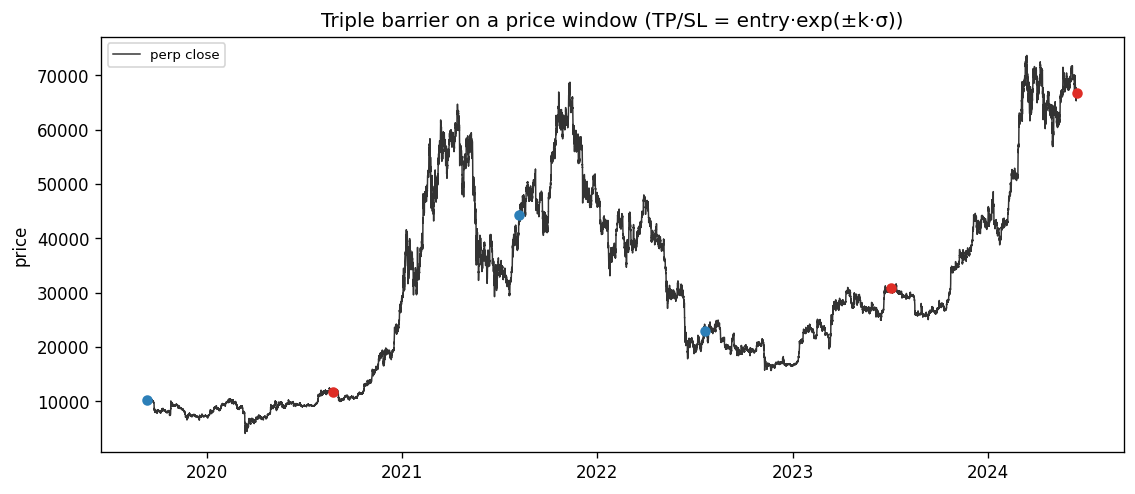

In [5]:
rows = []
for k in config.k_grid():
    for H in config.h_grid():
        Lk = lb.triple_barrier_labels(close_dev, k=k, H=H)
        rep = lb.label_report(Lk); rep["k"], rep["H"] = k, H
        rows.append(rep)
tbl = pd.DataFrame([{**{"k":r["k"],"H":r["H"]}, **{f: r["fractions"][f] for f in ("+1","0","-1")},
                     "trade_freq":r["trade_frequency"], "eff_N":r["sum_avg_uniqueness"],
                     "bar/cost":r["barrier_to_cost_ratio"], "hold":r["mean_bars_held"]} for r in rows])
display(tbl.round(3))
fig_bal = plots.plot_label_balance(rows, name="nb_label_balance.png", title="§4 баланс меток (dev)")
fig_bar = plots.plot_barriers_on_price(close_dev, L.frame, name="nb_barriers.png")
display(Image(str(fig_bal))); display(Image(str(fig_bar)))

## §5. Признаки: поток/деривативы в ядре, индикаторы — контроль

**Что делаем:** собираем причинную (t−1) матрицу из снапшота; показываем плечи `flow` и
`control`; кластеризуем коллинеарность и делаем train-only стабильный отбор.
**Зачем:** доказать прибавку потока НАД ценовым контролем (это и есть гейт §7); честная рамка —
на hourly это klines-ПРОКСИ микроструктуры, не тик.
**На что смотреть:** состав плеч, `d*` (fracdiff), отобранные стабильные фичи.


In [6]:
print("d* (fracdiff, dev-fit):", round(meta["d_star"], 3))
print("flow-плечо  :", meta["arm_flow"])
print("control-плечо:", meta["arm_control"])

# кластеры коллинеарности на flow-плече (для прозрачности)
corr = X[meta["arm_flow"]].corr().abs().fillna(0.0)
clusters = ft.cluster_collinear(corr, threshold=0.9)
print("\nколлинеарные кластеры (|corr|>0.9):", [c for c in clusters if len(c) > 1] or "нет сильных")

# train-only стабильный отбор на dev-фолдах (демонстрация; гейт §7 использует полные плечи)
from walk_forward import expanding_window_splits
Xy = X.loc[L.frame.index].copy(); Xy["__label__"] = L.frame["label"].to_numpy()
splits_dev = expanding_window_splits(len(Xy), n_splits=config.WF_N_SPLITS)
sel = ft.stable_select(Xy, meta["arm_flow"], "__label__", splits_dev, k=8)
print("\nтоп стабильных flow-фич:", sel)

d* (fracdiff, dev-fit): 0.2
flow-плечо  : ['basis', 'basis_chg', 'funding', 'funding_chg', 'tfi', 'cvd', 'vpin', 'active_addr_chg', 'tx_cnt_chg', 'addr_bal_chg', 'hashrate_chg', 'supply_chg', 'tod_sin', 'tod_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
control-плечо: ['ret_l1', 'ret_l2', 'ret_l3', 'ret_l6', 'ret_l12', 'ret_l24', 'ret_mean_6', 'ret_std_6', 'ret_mean_24', 'ret_std_24', 'ret_mean_72', 'ret_std_72', 'rsi', 'macd', 'ffd', 'tod_sin', 'tod_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

коллинеарные кластеры (|corr|>0.9): [['tod_sin', 'hour_sin'], ['tod_cos', 'hour_cos']]

топ стабильных flow-фич: ['month_cos', 'month_sin', 'funding_chg', 'supply_chg', 'hashrate_chg', 'addr_bal_chg', 'cvd', 'tfi']


## §6. Stage-1: классификатор стороны (лесенка)

**Что делаем:** лесенка `baseline → логистическая(калиброванная) → LightGBM(3-класс)`;
walk-forward OOF; proper-scoring (log-loss, MCC, balanced accuracy, confusion).
**Зачем:** каждый шаг должен доказывать прибавку; вероятность калибруется, т.к. далее идёт в
сайзинг (M4). Сторона выдаётся только на ±1; прогноз 0 = вне рынка.

**О модели (коротко).** *LightGBM* — градиентный бустинг на деревьях: ансамбль неглубоких
деревьев, каждое исправляет ошибки предыдущих; хорош для табличных микроструктурных признаков,
устойчив, быстр, даёт importance, нативно ест пропуски. Вход — матрица признаков t−1, выход —
вероятности классов {−1,0,+1}. *Калибровка* (isotonic) выравнивает вероятности под фактические
частоты, чтобы размер позиции на M4 опирался на честную `p`.
**На что смотреть:** OOF log-loss/MCC выше тривиального; матрица ошибок не вырождена.


OOF покрытие: 25050 из 50104 событий
accuracy           : 0.4648
balanced_accuracy  : 0.3328
MCC (multiclass)   : 0.0056
log-loss           : 0.9815  (тривиальный ~ 1.099 )


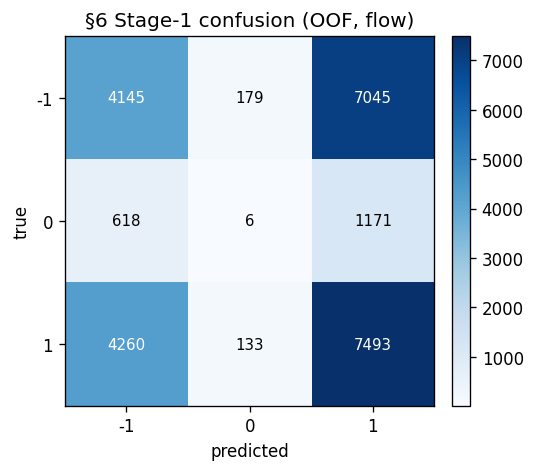


Примечание: directional accuracy — справочно; решение принимает экономика §7.


In [7]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, log_loss, accuracy_score
splits_oof = expanding_window_splits(len(y), n_splits=config.WF_N_SPLITS)
oof = pm.walk_forward_oof(X, y, w, meta["arm_flow"], splits_oof, model_name="lgbm")
yt = y.reindex(oof.index)
proba = oof[["p_down","p_flat","p_up"]].to_numpy()        # порядок классов [-1,0,1]
print("OOF покрытие:", len(oof), "из", len(y), "событий")
print("accuracy           :", round(accuracy_score(yt, oof['side']), 4))
print("balanced_accuracy  :", round(balanced_accuracy_score(yt, oof['side']), 4))
print("MCC (multiclass)   :", round(matthews_corrcoef(yt, oof['side']), 4))
print("log-loss           :", round(log_loss(yt, proba, labels=[-1,0,1]), 4), " (тривиальный ~", round(np.log(3),3), ")")
fig_cm = plots.plot_confusion(yt, oof['side'], name="nb_confusion.png", title="§6 Stage-1 confusion (OOF, flow)")
display(Image(str(fig_cm)))
print("\nПримечание: directional accuracy — справочно; решение принимает экономика §7.")

## §7. M3 ablation-гейт: поток vs ценовой контроль (дистрибутивно)

**Что делаем:** тот же пайплайн на flow-ядре и на close-price контроле при ИДЕНТИЧНОМ бюджете,
фолдах и обращении; решаем дистрибутивно на **де-перекрытых trade-ретёрнах**.
**Зачем:** на сырых перекрывающихся ретёрнах значимость завышена; гейт честен только на одной
сделке-на-ставку. Правило: flow проходит, если бьёт контроль net-cost Sharpe на БОЛЬШИНСТВЕ
CPCV-путей И paired-bootstrap Δ-CI исключает 0 (или Δ ≥ маржи из config).
**На что смотреть:** вердикт — continue (C) либо kill-switch → backlog B.


run_id=run_20260618T221953Z
{
  "return_basis": "de_overlapped_trade_level",
  "n_paths": 15,
  "flow_sharpe_mean": -2.821088154700158,
  "flow_sharpe_median": -2.9601890866950527,
  "control_sharpe_mean": -2.4479080931920363,
  "control_sharpe_median": -2.3814877407536335,
  "majority_flow_gt_control": 0.4666666666666667,
  "mean_delta_sharpe": -0.3731800615081214,
  "delta_ci_low": -0.8764417111525705,
  "delta_ci_high": 0.12751358567162424,
  "ci_level": 0.95,
  "majority_threshold": 0.5,
  "delta_margin": 0.0,
  "passed": false,
  "verdict": "FLOW FAILS gate \u2014 kill-switch to backlog B",
  "gate_model": "lgbm",
  "dsr_trial_count": 4
}
artifacts: /Users/tigran/python_projects_epta/personal_projects/diploma/v2_microstructure/reports/run_20260618T221953Z

return_basis : de_overlapped_trade_level
flow Sharpe  : mean -2.821 | median -2.960
ctrl Sharpe  : mean -2.448 | median -2.381
majority flow>ctrl : 0.467
Δ-Sharpe     : -0.373  CI[-0.876, 0.128]

>>> ВЕРДИКТ: FLOW FAILS gate — k

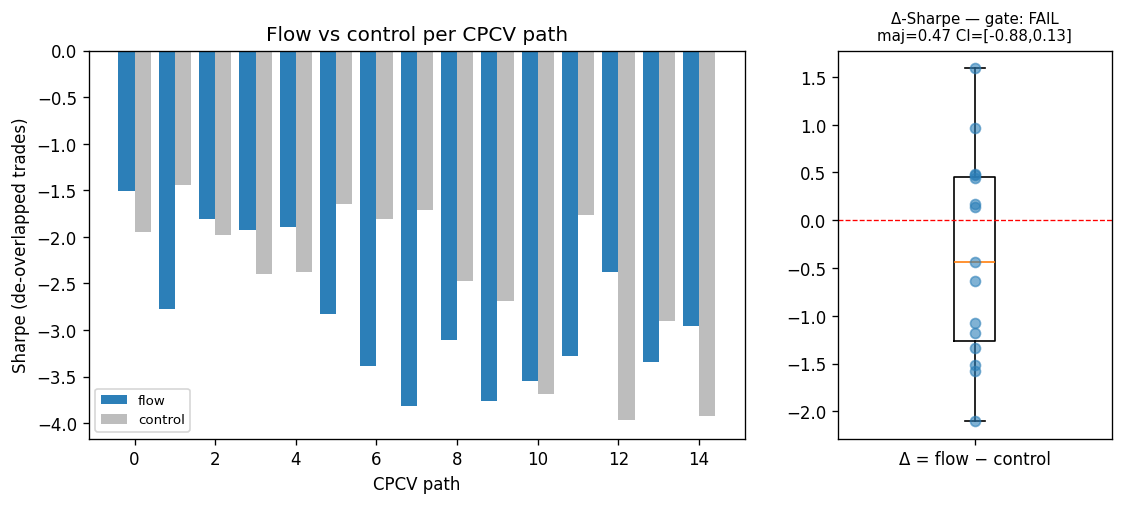

In [8]:
gate = ex.run_ablation_gate(k=config.K_DEFAULT, H=config.H_DEFAULT, model_name=config.QUICK_GATE_MODEL)
print("\nreturn_basis :", gate["return_basis"])
print("flow Sharpe  : mean %.3f | median %.3f" % (gate["flow_sharpe_mean"], gate["flow_sharpe_median"]))
print("ctrl Sharpe  : mean %.3f | median %.3f" % (gate["control_sharpe_mean"], gate["control_sharpe_median"]))
print("majority flow>ctrl :", round(gate["majority_flow_gt_control"], 3))
print("Δ-Sharpe     : %.3f  CI[%.3f, %.3f]" % (gate["mean_delta_sharpe"], gate["delta_ci_low"], gate["delta_ci_high"]))
print("\n>>> ВЕРДИКТ:", gate["verdict"])
# показать фигуру распределения (имя содержит run_id из последнего прогона)
figs = sorted(config.FIGURES_DIR.glob("*_ablation_gate.png"))
if figs: display(Image(str(figs[-1])))

## §8–§12 — отложено до M4–M5 (заглушка, НЕ исполняется)

Ниже — то, что появится после реализации вех M4–M5; код намеренно не выполняется в этом
ноутбуке (раздел §0–§7).

- **§8 Stage-2 (meta) + strategy:** мета-датасет ТОЛЬКО по ±1-барам
  (`side`=предсказанное ±1, `correct=1[barrier_label==side]`, `weight=|return@t1|`) →
  `train_meta_walkforward` → `meta_size`; стратегия: AFML-усреднение перекрывающихся ставок,
  кэп ±1, `simulate_strategy` с funding-carry, разложение PnL на `price_pnl`/`funding_pnl`.
- **§9 Экономика + переобучение:** DSR/PBO/psr на де-перекрытых сделках, breakeven (sweep 0–40бп),
  сравнение с `buy_and_hold`, кривая капитала, вклад funding в Sharpe (флаг carry-стратегии).
- **§10 Отчёт:** полный `reports/<run_id>/` (manifest, fold/cpcv метрики, OOF, trade_returns,
  pnl_decomposition, equity, turnover, baselines, ablation, delta).
- **§11 Sealed holdout (M7):** ОТДЕЛЬНАЯ защищённая ячейка — вскрытие ровно один раз; по
  умолчанию НЕ исполняется (здесь её нет намеренно).


In [9]:
# ЗАГЛУШКА §8–§12 — требует модулей M4–M5 (meta_model.py, strategy.py) и расширения evaluate.py.
RUN_M4_M5 = False
if RUN_M4_M5:
    raise NotImplementedError("M4–M5 ещё не реализованы; см. план FINAL PLAN v2")
print("§8–§12 отложены до M4–M5 (см. заглушку выше).")

§8–§12 отложены до M4–M5 (см. заглушку выше).


## §12. Вывод

**Честный вердикт первой итерации (§0–§7).** Инфраструктура верифицирована, антиутечка
зелёная. Ключевой результат — **M3 ablation-гейт на де-перекрытых сделках** (§7): он определяет,
несёт ли поток/деривативы независимую от цены экономическую информацию на hourly.

- Если гейт **FLOW PASSES** — продолжаем C: M4 (мета-лейблинг + стратегия с funding-carry и
  разложением PnL) и M5 (DSR/PBO/breakeven, полный отчёт), затем единственное вскрытие holdout.
- Если гейт **FLOW FAILS** — это легитимный **kill-switch на backlog B** (маркет-нейтральный
  StatArb), а НЕ повод подкручивать признаки под тест.

Текущий прогон в `QUICK_MODE`; для финального вердикта повторить с `config.QUICK_MODE = False`.
DA — только справочно; разворачиваем только при `DSR ≥ 0.95 И PBO ≤ 0.5`.
